# Newspaper Article Retrieval — 2024 US Presidential Election

Retrieves election-related news articles from politically diverse outlets for the month **before** the election: **Oct 5 – Nov 4, 2024**.

| Source | Leaning | Method |
|---|---|---|
| The Guardian | Left / Democratic | Guardian Open Platform API (free) |
| New York Times | Left / Democratic | NYT Article Search API (free) |
| Fox News | Right / Republican | GDELT DOC 2.0 API (no key needed) |
| Breitbart | Right / Republican | GDELT DOC 2.0 API (no key needed) |
| NY Post | Right / Republican | GDELT DOC 2.0 API (no key needed) |

**Get your free API keys:**
- Guardian: https://open-platform.theguardian.com/access/
- NYT: https://developer.nytimes.com/get-started
- GDELT: no key required

In [ ]:
import requests
import pandas as pd
import time
import os

# ── API Keys ────────────────────────────────────────────────────────────────────
GUARDIAN_API_KEY = "47346645-10a7-4288-aa66-7a7191f8f9eb"
NYT_API_KEY      = "QvQ4PUkpkCtnwmwkO1bLJNgfbkmhCK2NRh5PD4ypHZeAGpNr"

# ── Date range: one month before the election (Nov 5, 2024) ─────────────────────
START_DATE = "2024-10-05"
END_DATE   = "2024-11-04"

# ── Search query ────────────────────────────────────────────────────────────────
QUERY = "Trump OR Harris presidential election 2024"

os.makedirs("data", exist_ok=True)
print(f"Date range: {START_DATE} to {END_DATE}")

Date range: 2024-10-05 to 2024-11-04


## 1. The Guardian API (Democratic-leaning)

In [2]:
def fetch_guardian(query, from_date, to_date, api_key, max_pages=10):
    """
    Fetch articles from The Guardian Open Platform API.
    Free tier: unlimited historical access, up to 200 results per page.
    """
    base_url = "https://content.guardianapis.com/search"
    articles = []

    for page in range(1, max_pages + 1):
        params = {
            "q":           query,
            "from-date":   from_date,
            "to-date":     to_date,
            "api-key":     api_key,
            "page-size":   200,
            "page":        page,
            "show-fields": "headline,trailText,bodyText,wordcount",
            "order-by":    "oldest",
        }
        r = requests.get(base_url, params=params, timeout=30)
        r.raise_for_status()
        response = r.json()["response"]
        results  = response.get("results", [])

        if not results:
            break

        for item in results:
            f = item.get("fields", {})
            articles.append({
                "source":    "The Guardian",
                "leaning":   "Democratic",
                "date":      item["webPublicationDate"][:10],
                "title":     f.get("headline", item.get("webTitle", "")),
                "text":      f.get("bodyText") or f.get("trailText", ""),
                "section":   item.get("sectionName", ""),
                "url":       item.get("webUrl", ""),
                "wordcount": f.get("wordcount", ""),
            })

        total_pages = response.get("pages", 1)
        print(f"  page {page}/{min(max_pages, total_pages)} — {len(results)} articles")
        if page >= total_pages:
            break
        time.sleep(0.5)

    return pd.DataFrame(articles)


print("Fetching Guardian articles...")
df_guardian = fetch_guardian(QUERY, START_DATE, END_DATE, GUARDIAN_API_KEY)
print(f"Total: {len(df_guardian)} articles")
df_guardian.head(3)

Fetching Guardian articles...
  page 1/10 — 200 articles
  page 2/10 — 200 articles
  page 3/10 — 200 articles
  page 4/10 — 200 articles
  page 5/10 — 200 articles
  page 6/10 — 200 articles
  page 7/10 — 200 articles
  page 8/10 — 200 articles
  page 9/10 — 200 articles
  page 10/10 — 200 articles
Total: 2000 articles


,source,leaning,date,title,text,section,url,wordcount
0,The Guardian,Democratic,2024-10-05,Many cheered when banks eliminated ATM fees in...,It is getting increasingly difficult to find a...,Australia news,https://www.theguardian.com/australia-news/202...,633
1,The Guardian,Democratic,2024-10-05,Trump holds town hall event in North Carolina ...,Wrapping up our US politics new coverage for t...,US news,https://www.theguardian.com/us-news/live/2024/...,8701
2,The Guardian,Democratic,2024-10-05,Trump falsely touts endorsement from JP Morgan...,Donald Trump’s social media post that showed a...,US news,https://www.theguardian.com/us-news/2024/oct/0...,535


## 2. New York Times Article Search API (Democratic-leaning)

In [5]:
def fetch_nyt(query, begin_date, end_date, api_key, max_pages=3):
    """
    Fetch articles from the NYT Article Search API.
    Free tier: 500 requests/day, 10 requests/min.
    Each page returns 10 articles → max_pages=3 gives ~30 articles.
    """
    base_url = "https://api.nytimes.com/svc/search/v2/articlesearch.json"
    articles = []

    begin_fmt = begin_date.replace("-", "")
    end_fmt   = end_date.replace("-", "")

    for page in range(max_pages):
        params = {
            "q":          query,
            "begin_date": begin_fmt,
            "end_date":   end_fmt,
            "api-key":    api_key,
            "page":       page,
            "sort":       "oldest",
            "fl":         "headline,abstract,pub_date,section_name,web_url,word_count",
        }

        # Retry up to 3 times on rate-limit errors (NYT returns 401 or 429)
        for attempt in range(3):
            r = requests.get(base_url, params=params, timeout=30)
            if r.status_code in (401, 429):
                wait = 15 * (attempt + 1)
                print(f"  Rate limited (attempt {attempt+1}), waiting {wait}s...")
                time.sleep(wait)
                continue
            r.raise_for_status()
            break
        else:
            print(f"  Skipping page {page+1} after 3 failed attempts.")
            continue

        docs = r.json()["response"]["docs"]
        if not docs:
            break

        for doc in docs:
            articles.append({
                "source":    "New York Times",
                "leaning":   "Democratic",
                "date":      doc.get("pub_date", "")[:10],
                "title":     doc.get("headline", {}).get("main", ""),
                "text":      doc.get("abstract", ""),
                "section":   doc.get("section_name", ""),
                "url":       doc.get("web_url", ""),
                "wordcount": doc.get("word_count", ""),
            })

        print(f"  page {page + 1} — {len(docs)} articles")
        time.sleep(12)  # 12s gap → safely under 10 req/min limit

    return pd.DataFrame(articles)


print("Fetching NYT articles (30 articles / 3 pages)...")
df_nyt = fetch_nyt(QUERY, START_DATE, END_DATE, NYT_API_KEY, max_pages=3)
print(f"Total: {len(df_nyt)} articles")
df_nyt.head(3)

Fetching NYT articles (30 articles / 3 pages)...
  page 1 — 10 articles
  page 2 — 10 articles
  page 3 — 10 articles
Total: 30 articles


,source,leaning,date,title,text,section,url,wordcount
0,New York Times,Democratic,2024-10-05,Aides Say Trump Resisted Sending Federal Funds...,He changed his mind after being shown data tha...,U.S.,https://www.nytimes.com/2024/10/04/us/politics...,652
1,New York Times,Democratic,2024-10-05,Behind Trump’s Views on Ukraine: Putin’s Gambi...,The roots of Donald Trump’s animus toward Ukra...,U.S.,https://www.nytimes.com/2024/10/05/us/politics...,3522
2,New York Times,Democratic,2024-10-05,"Campaigning for Harris, Women Share Their Abor...",The Harris campaign is trying to transform wom...,U.S.,https://www.nytimes.com/2024/10/05/us/politics...,1471


## 3. GDELT DOC 2.0 — Fox News, Breitbart, NY Post (Republican-leaning)

GDELT monitors global news 24/7 across thousands of outlets. No API key required.  
We filter by domain to get right-leaning coverage of the same period.

In [6]:
def fetch_gdelt_domain(keyword, domain, start_dt, end_dt, max_records=250):
    """
    Fetch articles from GDELT DOC 2.0 API filtered by a specific news domain.
    start_dt / end_dt format: YYYYMMDDHHMMSS
    Max 250 results per request (GDELT hard limit).
    """
    base_url = "https://api.gdeltproject.org/api/v2/doc/doc"
    params = {
        "query":         f"{keyword} domain:{domain}",
        "mode":          "artlist",
        "maxrecords":    max_records,
        "startdatetime": start_dt,
        "enddatetime":   end_dt,
        "format":        "json",
        "sort":          "DateAsc",
    }
    r = requests.get(base_url, params=params, timeout=60)
    r.raise_for_status()

    if not r.text.strip():
        return []

    try:
        data = r.json()
    except Exception:
        return []

    return data.get("articles", [])


# Domain → (display name, leaning)
REPUBLICAN_SOURCES = {
    "foxnews.com":     ("Fox News",    "Republican"),
    "breitbart.com":   ("Breitbart",   "Republican"),
    "nypost.com":      ("NY Post",     "Republican"),
    "dailycaller.com": ("Daily Caller","Republican"),
}

# GDELT datetime format: YYYYMMDDHHMMSS
START_GDELT = START_DATE.replace("-", "") + "000000"
END_GDELT   = END_DATE.replace("-", "")   + "235959"

gdelt_rows = []
keyword = "Trump Harris election"

print("Fetching GDELT articles...")
for domain, (source_name, leaning) in REPUBLICAN_SOURCES.items():
    results = fetch_gdelt_domain(keyword, domain, START_GDELT, END_GDELT)
    print(f"  [{source_name}]: {len(results)} articles")
    for item in results:
        raw_date = item.get("seendate", "")[:8]  # YYYYMMDD
        try:
            date_fmt = pd.to_datetime(raw_date, format="%Y%m%d").strftime("%Y-%m-%d")
        except Exception:
            date_fmt = ""
        gdelt_rows.append({
            "source":    source_name,
            "leaning":   leaning,
            "date":      date_fmt,
            "title":     item.get("title", ""),
            "text":      "",   # GDELT artlist does not return full body text
            "section":   "",
            "url":       item.get("url", ""),
            "wordcount": "",
        })
    time.sleep(1)  # be polite

df_gdelt = pd.DataFrame(gdelt_rows)
print(f"\nGDELT total: {len(df_gdelt)} articles")
df_gdelt.head(3)

Fetching GDELT articles...
  [Fox News]: 250 articles
  [Breitbart]: 250 articles
  [NY Post]: 247 articles
  [Daily Caller]: 190 articles

GDELT total: 937 articles


,source,leaning,date,title,text,section,url,wordcount
0,Fox News,Republican,2024-10-05,Texas residents express frustration with the e...,,,https://www.foxnews.com/media/texas-residents-...,
1,Fox News,Republican,2024-10-05,Why the slow collapse of Harris - Walz wont st...,,,https://www.foxnews.com/opinion/why-slow-colla...,
2,Fox News,Republican,2024-10-05,Trump admits to not feeling safe on campaign t...,,,https://www.foxnews.com/media/trump-admits-not...,


## 4. Combine All Sources & Save

In [7]:
df_all = pd.concat([df_guardian, df_nyt, df_gdelt], ignore_index=True)

# Normalise and filter dates
df_all["date"] = pd.to_datetime(df_all["date"], errors="coerce")
mask = (df_all["date"] >= START_DATE) & (df_all["date"] <= END_DATE)
df_all = df_all[mask].copy()

# Drop duplicate URLs
df_all = df_all.drop_duplicates(subset="url").sort_values("date").reset_index(drop=True)

print("=== Combined dataset ===")
print(df_all.groupby(["source", "leaning"]).size().to_string())
print(f"\nTotal articles : {len(df_all)}")
print(f"Date range     : {df_all['date'].min().date()} → {df_all['date'].max().date()}")
df_all.head()

=== Combined dataset ===
source          leaning   
Breitbart       Republican     250
Daily Caller    Republican     175
Fox News        Republican     250
NY Post         Republican     232
New York Times  Democratic      30
The Guardian    Democratic    2000

Total articles : 2937
Date range     : 2024-10-05 → 2024-11-04


,source,leaning,date,title,text,section,url,wordcount
0,The Guardian,Democratic,2024-10-05,Many cheered when banks eliminated ATM fees in...,It is getting increasingly difficult to find a...,Australia news,https://www.theguardian.com/australia-news/202...,633
1,The Guardian,Democratic,2024-10-05,Classic NRL grand final in the offing as histo...,Penrith wear the title of modern rugby league’...,Sport,https://www.theguardian.com/sport/2024/oct/06/...,927
2,The Guardian,Democratic,2024-10-05,Players responsible for Manchester United resu...,Harry Maguire has urged his teammates not to b...,Football,https://www.theguardian.com/football/2024/oct/...,509
3,The Guardian,Democratic,2024-10-05,White House blasts false claims about Hurrican...,The White House moved Saturday to quash claims...,US news,https://www.theguardian.com/us-news/2024/oct/0...,805
4,The Guardian,Democratic,2024-10-05,Key match-ups: where the 2024 NRL grand final ...,Nathan Cleary v Ryan Papenhuyzen When Brisbane...,Sport,https://www.theguardian.com/sport/2024/oct/06/...,789


In [8]:
# Save
df_all.to_csv("data/newspaper_articles.csv", index=False)
df_all[df_all["leaning"] == "Democratic"].to_csv("data/newspaper_democratic.csv", index=False)
df_all[df_all["leaning"] == "Republican"].to_csv("data/newspaper_republican.csv", index=False)

print("Saved:")
print("  data/newspaper_articles.csv   (all sources)")
print("  data/newspaper_democratic.csv (Guardian + NYT)")
print("  data/newspaper_republican.csv (Fox News, Breitbart, NY Post, Daily Caller)")

Saved:
  data/newspaper_articles.csv   (all sources)
  data/newspaper_democratic.csv (Guardian + NYT)
  data/newspaper_republican.csv (Fox News, Breitbart, NY Post, Daily Caller)


## 5. Quick Overview

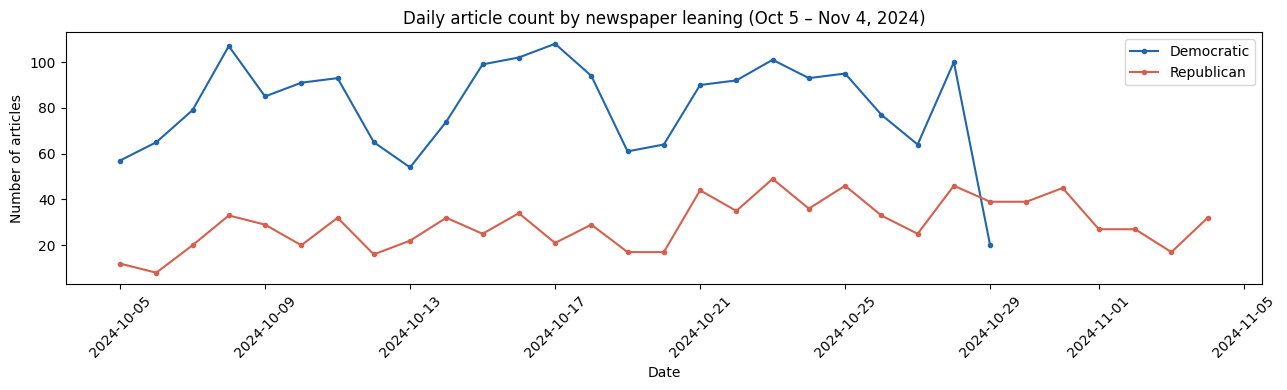

In [9]:
import matplotlib.pyplot as plt

daily = (
    df_all.groupby(["date", "leaning"])
    .size()
    .reset_index(name="count")
)

fig, ax = plt.subplots(figsize=(13, 4))
colors = {"Democratic": "#2166ac", "Republican": "#d6604d"}

for leaning, color in colors.items():
    subset = daily[daily["leaning"] == leaning]
    ax.plot(subset["date"], subset["count"],
            label=leaning, color=color, marker="o", ms=3, linewidth=1.5)

ax.set_title("Daily article count by newspaper leaning (Oct 5 – Nov 4, 2024)")
ax.set_xlabel("Date")
ax.set_ylabel("Number of articles")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("data/newspaper_daily_counts.png", dpi=150)
plt.show()